In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing


import urllib.request

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import regularizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping



np.random.seed(41)
tf.random.set_seed(41)


# Questão 1

## Definindo a função f(x)

In [2]:
def f(x):
    return (10*x**5) + (5*x**4) + (2*x**3) - (0.5*x**2) + (3*x + 2)

## Gerando os dados de treino e teste

In [3]:
X = np.linspace(0, 5, 2000).reshape(-1, 1)
y = f(X)

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

#### Normalizando os dados

In [5]:
normalizador = MinMaxScaler()
X_treino = normalizador.fit_transform(X_treino)
X_teste = normalizador.transform(X_teste)

## Arquitetura da Rede Neural

In [6]:
# Função que calcula a quantidade máxima de neurônios na camada oculta da rede neural
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

num_max_neuronio(X, 1) 

66

In [7]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.01), metrics=['mae'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
history = model.fit(X_treino, y_treino,
            epochs=50,
            batch_size=32,
            validation_data = (X_teste, y_teste),
            verbose=0)

## Avaliando no conjunto de Teste

In [9]:
resultado = model.evaluate(X_teste, y_teste)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 596.2376 - mae: 18.3743


## Função Real x Função Aproximada

In [10]:
history_df = pd.DataFrame(history.history)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


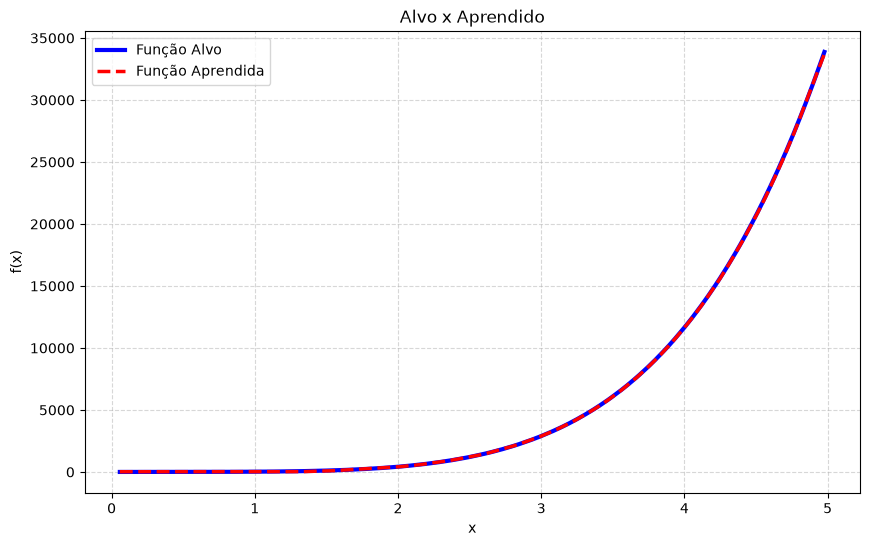

In [11]:
y_predito = model.predict(X_teste)
X_teste_original = normalizador.inverse_transform(X_teste)

indices_ordenados = np.argsort(X_teste_original, axis=0).flatten()

X_plot = X_teste_original[indices_ordenados]
y_real_plot = y_teste[indices_ordenados]
y_predito_plot = y_predito[indices_ordenados]

plt.figure(figsize=(10, 6))
plt.plot(X_plot, y_real_plot, label='Função Alvo', color='blue', linewidth=3)
plt.plot(X_plot, y_predito_plot, label='Função Aprendida', color='red', linestyle='dashed', linewidth=2.5)

plt.title('Alvo x Aprendido')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Curva de erro no treinamento

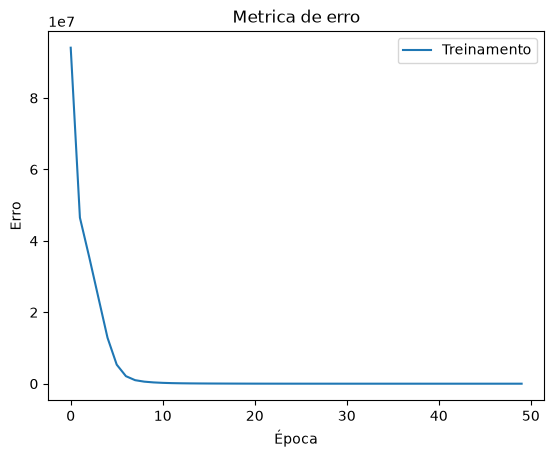

In [12]:
plt.plot(history_df['loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento'])
plt.show()


## Curva de erro no teste

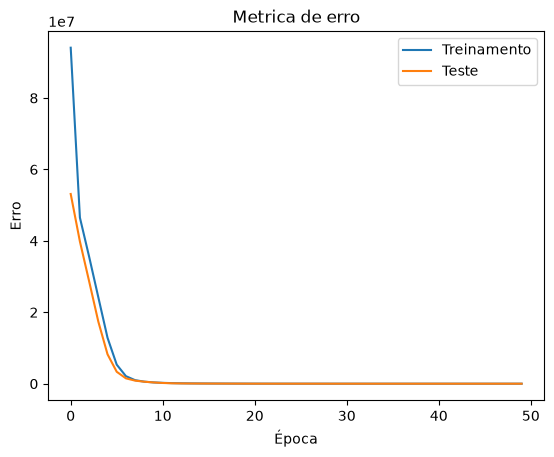

In [13]:
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Teste'])
plt.show()


## Métricas de avaliação

In [14]:
mse = resultado[0]
rmse = np.sqrt(resultado[0])
mae = resultado[1]
amplitude = f(5) - f(0)

nrmse = rmse / amplitude

print(f"MSE: {mse:.4f}\n"
      f"RMSE: {rmse:.4f}\n"  \
      f"NRMSE: {nrmse:.4f}"\
      f"\nMAE: {mae:.4f}")

MSE: 596.2376
RMSE: 24.4180
NRMSE: 0.0007
MAE: 18.3743


## California Housing Dataset

In [15]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(data = california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Não temos valores nulos, todas as colunas estão com os tipos numéricos.

In [17]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Dicionário de Dados: California Housing (1990)

Cada linha deste dataset não representa uma casa individual, mas sim um **Grupo de Quarteirões** (block group), que é a menor unidade geográfica do Censo dos EUA (abrigando de 600 a 3.000 pessoas).

| Variável (Atributo) | Descrição | Unidade / Escala | Tipo |
| :--- | :--- | :--- | :--- |
| **`MedInc`** | Renda mediana das famílias do quarteirão. | Dezenas de milhares de US$ *(Ex: 8.3 = $83.000/ano)* | `float64` |
| **`HouseAge`** | Idade mediana das casas do quarteirão. | Anos | `float64` |
| **`AveRooms`** | Número médio de cômodos totais por domicílio. | Quantidade de cômodos | `float64` |
| **`AveBedrms`** | Número médio de quartos de dormir por domicílio. | Quantidade de quartos | `float64` |
| **`Population`** | População total que reside no quarteirão. | Número de Pessoas | `float64` |
| **`AveOccup`** | Número médio de ocupantes (moradores) por casa. | Número de Pessoas | `float64` |
| **`Latitude`** | Coordenada de latitude do quarteirão. | Graus Geográficos | `float64` |
| **`Longitude`** | Coordenada de longitude do quarteirão. | Graus Geográficos | `float64` |
| **`MedHouseVal`** | Valor mediano dos imóveis no quarteirão. | Centenas de milhares de US$ *(Ex: 4.5 = $450.000)* | `float64` |


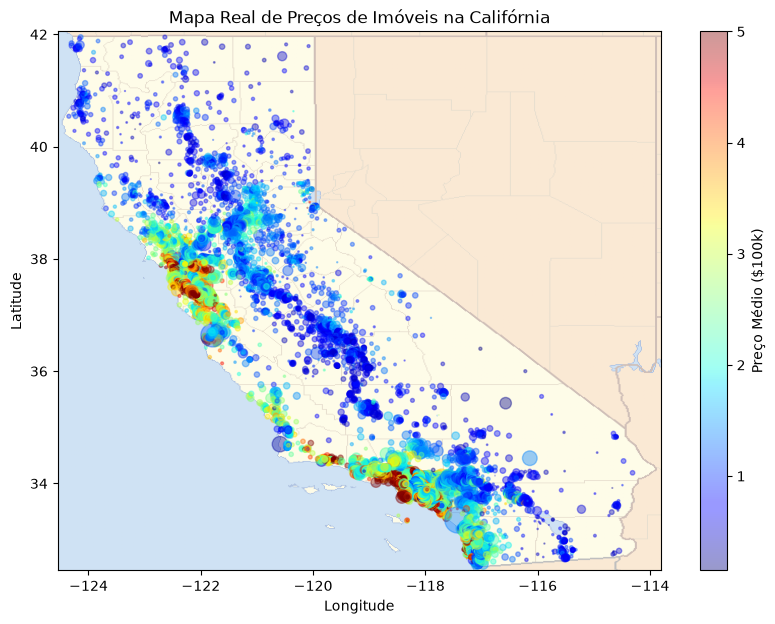

In [18]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/images/end_to_end_project/california.png"
urllib.request.urlretrieve(url, "img/california.png")
mapa_img = mpimg.imread("img/california.png")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(x=df['Longitude'], y=df['Latitude'], 
                      alpha=0.4, 
                      s=df['Population']/100, 
                      c=df['MedHouseVal'], 
                      cmap=plt.get_cmap("jet"))

plt.imshow(mapa_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)

plt.colorbar(scatter, label='Preço Médio ($100k)')
plt.title('Mapa Real de Preços de Imóveis na Califórnia')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

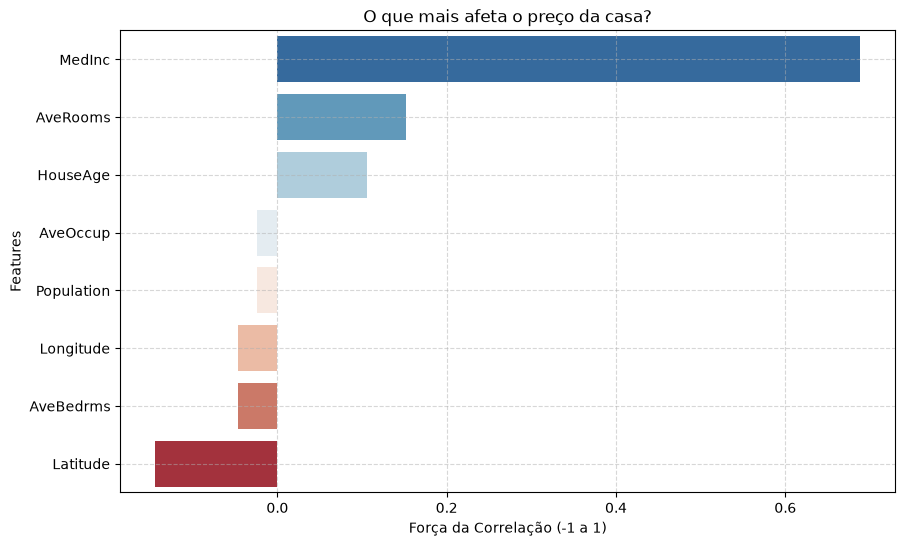

In [19]:
plt.figure(figsize=(10, 6))

# Calcula a correlação, pega só a coluna do alvo, remove a correlação do alvo com ele mesmo e ordena
correlacao_alvo = df.corr()[['MedHouseVal']].drop('MedHouseVal').sort_values(by='MedHouseVal', ascending=False)

sns.barplot(x=correlacao_alvo['MedHouseVal'], y =correlacao_alvo.index, hue =correlacao_alvo.index, palette='RdBu_r', legend = False)

plt.title('O que mais afeta o preço da casa?')
plt.xlabel('Força da Correlação (-1 a 1)')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

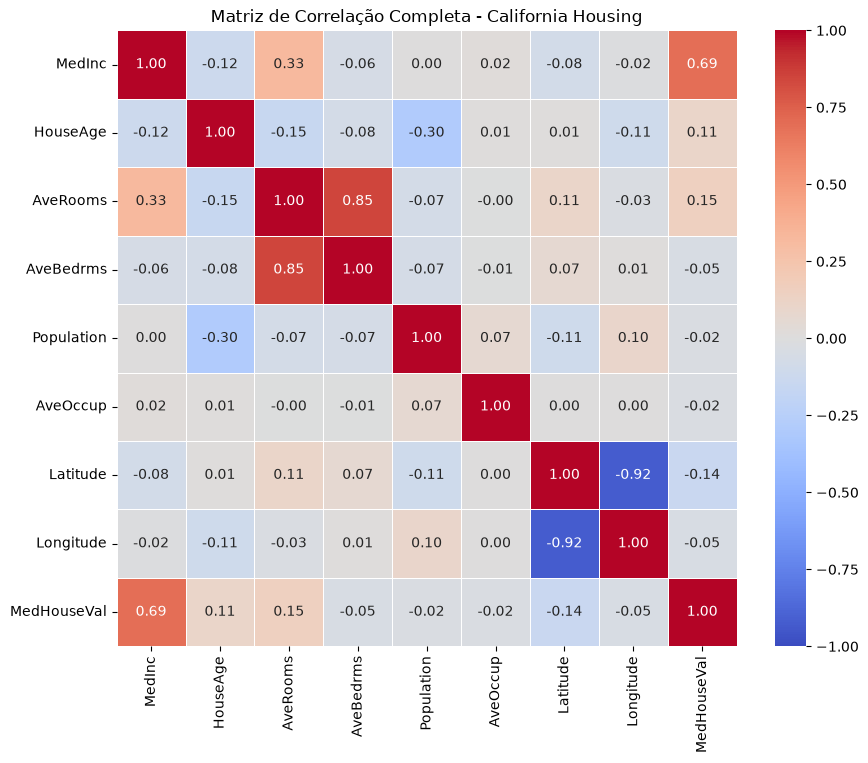

In [20]:
# Matriz de Correlação de TODAS as variáveis entre si
plt.figure(figsize=(10, 8))
# O comando df.corr() calcula a correlação de Pearson (tudo contra tudo)
matriz_correlacao = df.corr()
# Desenhando o Mapa de Calor
# annot=True exibe os números, cmap é a paleta de cores (coolwarm = azul pro negativo, vermelho pro positivo)
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação Completa - California Housing")
plt.show()


As features AveRooms e AveBedrms tem muita correlação entre si, podemos remover uma delas.

In [21]:
df.drop(columns=['AveRooms'], inplace = True)

df.columns

Index(['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup', 'Latitude',
       'Longitude', 'MedHouseVal'],
      dtype='str')

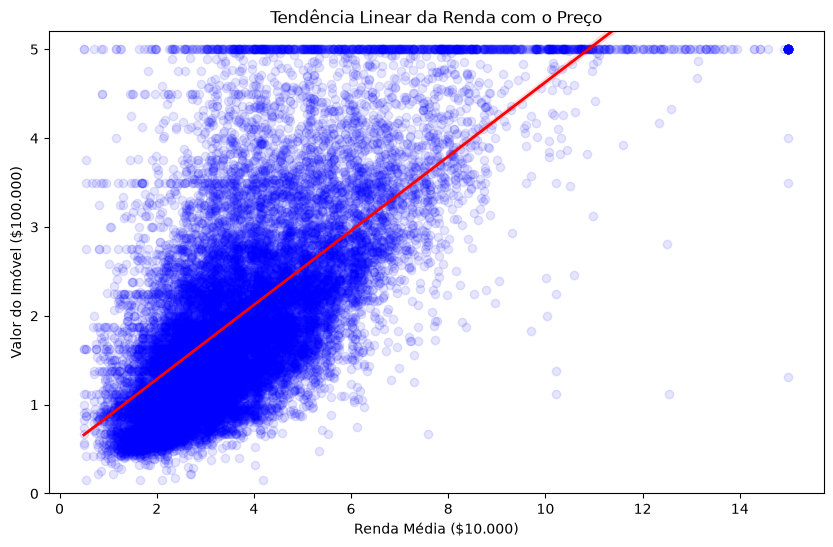

In [22]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df['MedInc'], y=df['MedHouseVal'], 
            scatter_kws={'alpha':0.1, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2})   

plt.title('Tendência Linear da Renda com o Preço')
plt.xlabel('Renda Média ($10.000)')
plt.ylabel('Valor do Imóvel ($100.000)')
plt.ylim(0, 5.2)
plt.show()

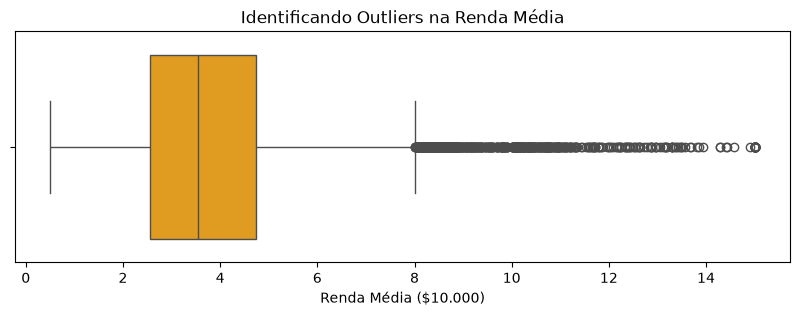

In [23]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df['MedInc'], color='orange')

plt.title('Identificando Outliers na Renda Média')
plt.xlabel('Renda Média ($10.000)')
plt.show()

Os outliers nesse caso não parece ruído, há a possibilidade de pessoas que recebam esse salário

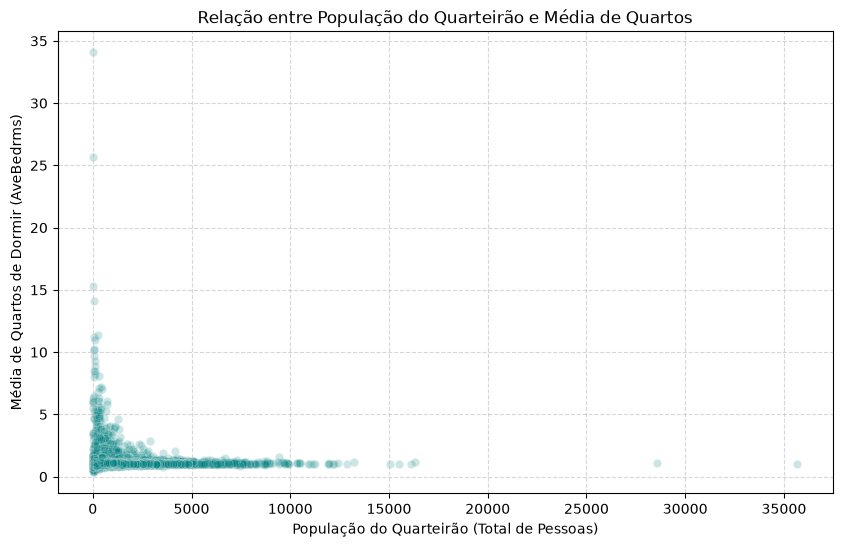

In [24]:
# Gráfico de Dispersão: População vs Média de Quartos
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['Population'], y=df['AveBedrms'], 
                alpha=0.2, color='teal')

plt.title('Relação entre População do Quarteirão e Média de Quartos')
plt.xlabel('População do Quarteirão (Total de Pessoas)')
plt.ylabel('Média de Quartos de Dormir (AveBedrms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Essas colunas apresentam outliers muito isolados, serão removidos

In [25]:
df_sem_outliers = df[(df['Population'] < 15000) & (df['AveBedrms'] < 10)]

## Feature Engineering

In [30]:
import numpy as np

# Função Matemática do Haversine (Calcula distância GPS em linha reta)
def distancia_haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Retorna a distância em Quilômetros

# Coordenadas de grandes praias/cidades litorâneas da Califórnia (Do Norte ao Sul)
praias_california = [
    (40.8021, -124.1637), # Praia de Eureka (Extremo Norte)
    (37.7749, -122.4194), # San Francisco (Centro-Norte)
    (36.6002, -121.8947), # Monterey Bay (Centro)
    (34.4208, -119.6982), # Santa Barbara (Centro-Sul)
    (34.0522, -118.2437), # Praia de Santa Monica / Los Angeles (Sul)
    (32.7157, -117.1611)  # San Diego (Extremo Sul)
]

# Função que testa todas as praias e escolhe a mais perto
def distancia_praia_mais_proxima(linha):
    distancias = []
    for praia_lat, praia_lon in praias_california:
        # Calcula a distância dessa casa para a praia do loop
        dist = distancia_haversine(linha['Latitude'], linha['Longitude'], praia_lat, praia_lon)
        distancias.append(dist)
    
    # Retorna apenas a distância para a praia mais próxima
    return min(distancias)

df['distance_beach'] = df.apply(distancia_praia_mais_proxima, axis=1)

display(df[['Latitude', 'Longitude', 'MedHouseVal', 'distance_beach']].head())

,Latitude,Longitude,MedHouseVal,distance_beach
0,37.88,-122.23,4.526,20.329542
1,37.86,-122.22,3.585,19.908065
2,37.85,-122.24,3.521,17.835390
3,37.85,-122.25,3.413,17.064123
4,37.85,-122.25,3.422,17.064123


## Normalizando os dados

In [31]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

In [32]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
normalizador = MinMaxScaler()
X_treino = normalizador.fit_transform(X_treino)
X_teste = normalizador.transform(X_teste)

## Arquitetura da rede neural

In [36]:
model = Sequential()

model.add(Input(shape=(X_treino.shape[1],)))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience= 50,              
    restore_best_weights=True
)


history = model.fit(X_treino, y_treino,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=1)

Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - loss: 0.7760 - mae: 0.6213 - val_loss: 0.5101 - val_mae: 0.5075
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 0.4927 - mae: 0.5041 - val_loss: 0.4950 - val_mae: 0.5038
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - loss: 0.4758 - mae: 0.4934 - val_loss: 0.4837 - val_mae: 0.4994
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - loss: 0.4608 - mae: 0.4838 - val_loss: 0.4719 - val_mae: 0.4940
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.4476 - mae: 0.4752 - val_loss: 0.4660 - val_mae: 0.4896
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.4381 - mae: 0.4687 - val_loss: 0.4610 - val_mae: 0.4851
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - loss: 0.4301 - mae: 0.4632 - val_loss: 0.4549 - val_mae: 0.4804
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 0.4229 - mae: 0.4584 - val_loss: 0.4509 - val_mae: 0.4791
Epoch 9/200
413/413 ━━━━━━━━━━━━

In [38]:
history_df = pd.DataFrame(history.history)

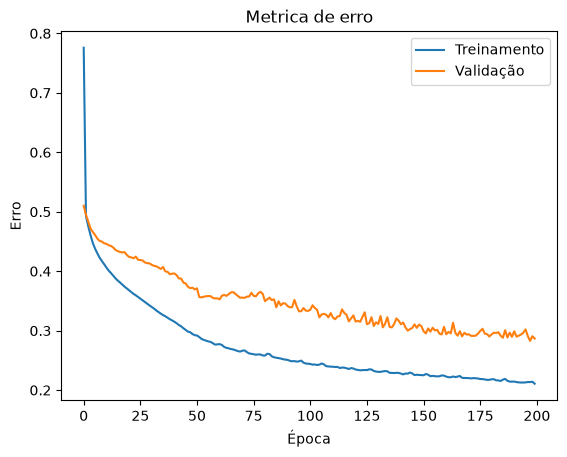

In [39]:
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()


Pelas métricas de erro, a rede neural teve overfitting

In [40]:
model = Sequential()

model.add(Input(shape=(X_treino.shape[1],)))

model.add(Dense(128, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(128, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.0001), metrics=['mae'])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,033 (109.50 KB)

 Trainable params: 28,033 (109.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
history = model.fit(X_treino, y_treino,
            epochs=10000,
            batch_size=64,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=1)

Epoch 1/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5512 - mae: 1.0505 - val_loss: 1.7513 - val_mae: 0.7267
Epoch 2/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - loss: 1.9659 - mae: 0.8692 - val_loss: 1.5864 - val_mae: 0.6693
Epoch 3/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 1.7850 - mae: 0.8061 - val_loss: 1.5090 - val_mae: 0.6510
Epoch 4/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 1.6429 - mae: 0.7530 - val_loss: 1.4133 - val_mae: 0.6143
Epoch 5/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 1.5760 - mae: 0.7344 - val_loss: 1.4191 - val_mae: 0.6294
Epoch 6/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - loss: 1.5031 - mae: 0.7086 - val_loss: 1.3515 - val_mae: 0.5970
Epoch 7/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 1.4606 - mae: 0.6969 - val_loss: 1.3494 - val_mae: 0.6035
Epoch 8/10000
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 1.4141 - mae: 0.6826 - val_loss: 1.3148 - val_mae: 0.5976
Epoch 9/10000
207/

In [42]:
history_df = pd.DataFrame(history.history)

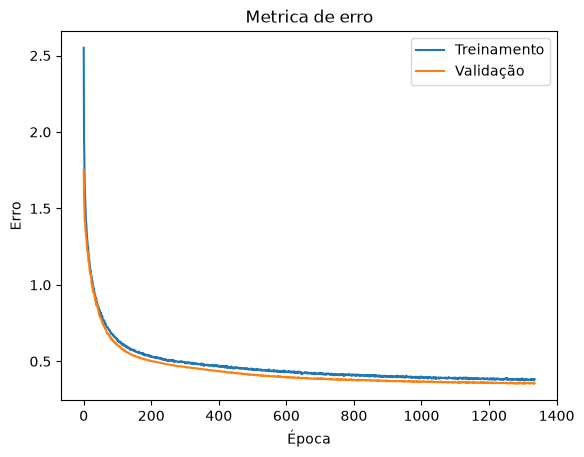

In [43]:
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()


In [44]:
history_df['loss'].min()

np.float64(0.3747083842754364)

In [45]:
np.sqrt(history_df['loss'].min())

np.float64(0.6121342861459701)

## Prevendo os valores do Teste

In [46]:
resultado = model.evaluate(X_teste, y_teste)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 0.3554 - mae: 0.3753


In [47]:
mse = resultado[0]
rmse = np.sqrt(resultado[0])
mae = resultado[1]

print(f"MSE: {mse:.4f}\n"
      f"RMSE: {rmse:.4f}\n"  \
      f"MAE: {mae:.4f}")

MSE: 0.3554
RMSE: 0.5961
MAE: 0.3753


## Comparação do valor previsto para o valor Real

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step


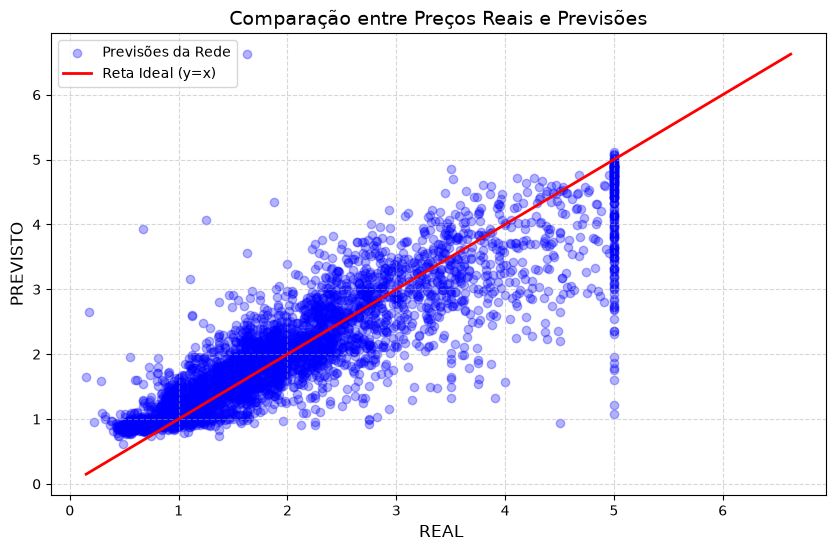

In [55]:
y_predito = model.predict(X_teste).flatten()
# Definindo o tamanho do gráfico para ficar elegante
plt.figure(figsize=(10, 6))
plt.scatter(y_teste, y_predito, alpha=0.3, color='blue', label='Previsões da Rede')

min_val = min(y_teste.min(), y_predito.min())
max_val = max(y_teste.max(), y_predito.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Reta Ideal (y=x)')
# 4. Enfeitando o gráfico para o relatório
plt.title('Comparação entre Preços Reais e Previsões', fontsize=14)
plt.xlabel(' REAL', fontsize=12)
plt.ylabel(' PREVISTO ', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
# Exibe a obra de arte
plt.show()


## Salvando a rede neural com os pesos aprendidos

In [ ]:
import joblib

model.save('modelo_california.keras')
joblib.dump(normalizador, 'normalizador_california.pkl')

['normalizador_california.pkl']